In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import statsmodels.api as sm
from itertools import combinations

sns.set_style("whitegrid")

In [2]:
INPUT_GPKG = r"../04_LCZ_Classifications/02_LCZ_Classification/LCZ_Classification.gpkg"

gdf = gpd.read_file(INPUT_GPKG)
print(f"Loaded {len(gdf)} rows, columns: {list(gdf.columns)}")

RESPONSE_VARS = [c for c in ["Night", "Morning", "Afternoon", "Evening"] if c in gdf.columns]
CONTINUOUS_PREDICTORS = ["ImperviousSurface_mean", "TreeCanopy_mean"]
CATEGORICAL_PREDICTORS = ["LC_Majority", "LCZ_final"]

print(f"Response variables found: {RESPONSE_VARS}")

Loaded 4255 rows, columns: ['GRID_ID', 'Night', 'Morning', 'Evening', 'BuildingFootprint_mean', 'ImperviousSurface_mean', 'TreeCanopy_mean', 'LC_Majority', 'LCZ_final', 'Strictness_Level', 'geometry']
Response variables found: ['Night', 'Morning', 'Evening']


In [3]:
cols_of_interest = RESPONSE_VARS + CONTINUOUS_PREDICTORS + CATEGORICAL_PREDICTORS

missing_summary = gdf[cols_of_interest].isna().sum().to_frame("n_missing")
missing_summary["pct_missing"] = 100 * missing_summary["n_missing"] / len(gdf)
print(missing_summary)

# rows usable for analysis: need all response + continuous predictors present
# (categoricals handled separately since NaN there just means "unclassified")
analysis_df = gdf.dropna(subset=RESPONSE_VARS + CONTINUOUS_PREDICTORS).copy()
print(f"\nRows with complete response + continuous predictor data: {len(analysis_df)} / {len(gdf)}")

                        n_missing  pct_missing
Night                           0          0.0
Morning                         0          0.0
Evening                         0          0.0
ImperviousSurface_mean          0          0.0
TreeCanopy_mean                 0          0.0
LC_Majority                     0          0.0
LCZ_final                       0          0.0

Rows with complete response + continuous predictor data: 4255 / 4255


In [4]:
print("Continuous variables:")
print(analysis_df[RESPONSE_VARS + CONTINUOUS_PREDICTORS].describe())

print("\nLC_Majority value counts:")
print(analysis_df["LC_Majority"].value_counts(dropna=False))

print("\nLCZ_final value counts:")
print(analysis_df["LCZ_final"].value_counts(dropna=False))

Continuous variables:
             Night      Morning      Evening  ImperviousSurface_mean  \
count  4255.000000  4255.000000  4255.000000             4255.000000   
mean    292.673676   298.055756   303.051392               12.862504   
std       2.044317     2.989654     2.546523               20.231440   
min     287.659119   290.530518   296.618530                0.000000   
25%     291.082550   295.723083   301.039825                0.134563   
50%     292.557800   297.922089   303.163666                1.321043   
75%     294.240402   300.385605   305.222870               19.944194   
max     298.893280   307.880280   309.486755               82.178957   

       TreeCanopy_mean  
count      4255.000000  
mean          2.847830  
std           4.729232  
min           0.000000  
25%           0.044085  
50%           0.614209  
75%           3.367237  
max          36.790279  

LC_Majority value counts:
LC_Majority
82.0    1683
71.0    1198
23.0     663
22.0     273
11.0     156


                        Night  Morning  Evening  ImperviousSurface_mean  \
Night                   1.000    0.405    0.503                   0.609   
Morning                 0.405    1.000    0.706                   0.353   
Evening                 0.503    0.706    1.000                   0.510   
ImperviousSurface_mean  0.609    0.353    0.510                   1.000   
TreeCanopy_mean         0.404    0.127    0.312                   0.389   

                        TreeCanopy_mean  
Night                             0.404  
Morning                           0.127  
Evening                           0.312  
ImperviousSurface_mean            0.389  
TreeCanopy_mean                   1.000  


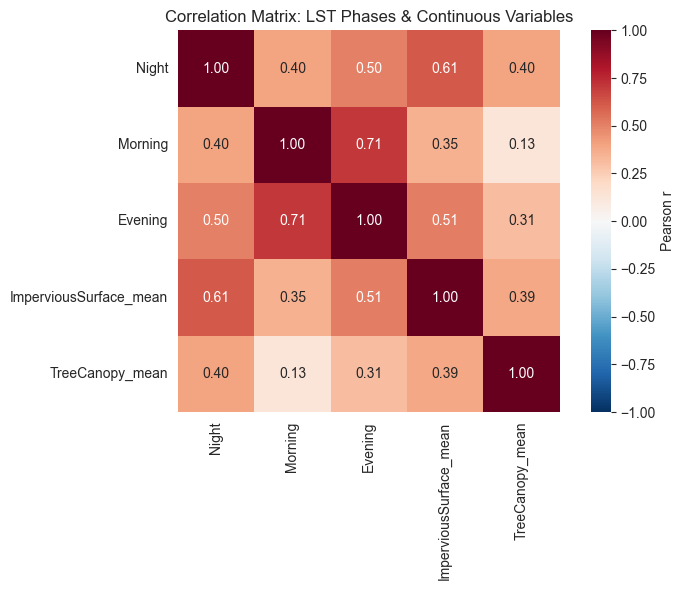

In [5]:
corr_cols = RESPONSE_VARS + CONTINUOUS_PREDICTORS
corr_matrix = analysis_df[corr_cols].corr(method="pearson")

print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={"label": "Pearson r"}
)
ax.set_title("Correlation Matrix: LST Phases & Continuous Variables")
plt.tight_layout()
plt.show()

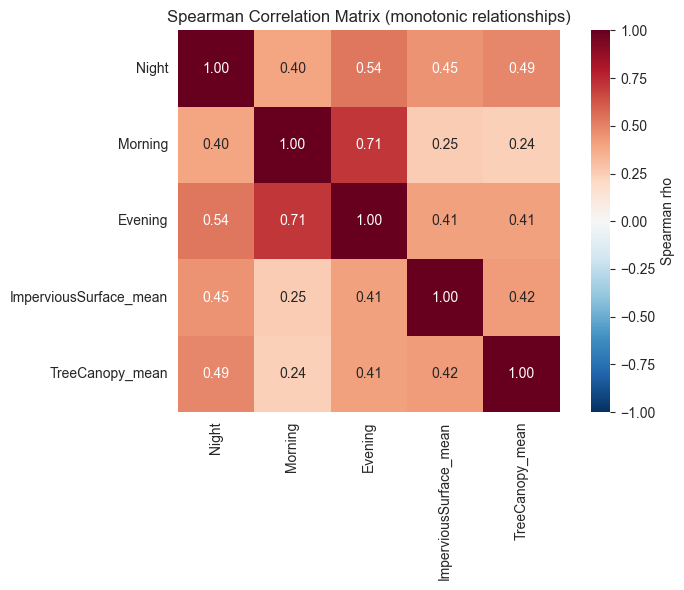

In [6]:
spearman_matrix = analysis_df[corr_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    spearman_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={"label": "Spearman rho"}
)
ax.set_title("Spearman Correlation Matrix (monotonic relationships)")
plt.tight_layout()
plt.show()

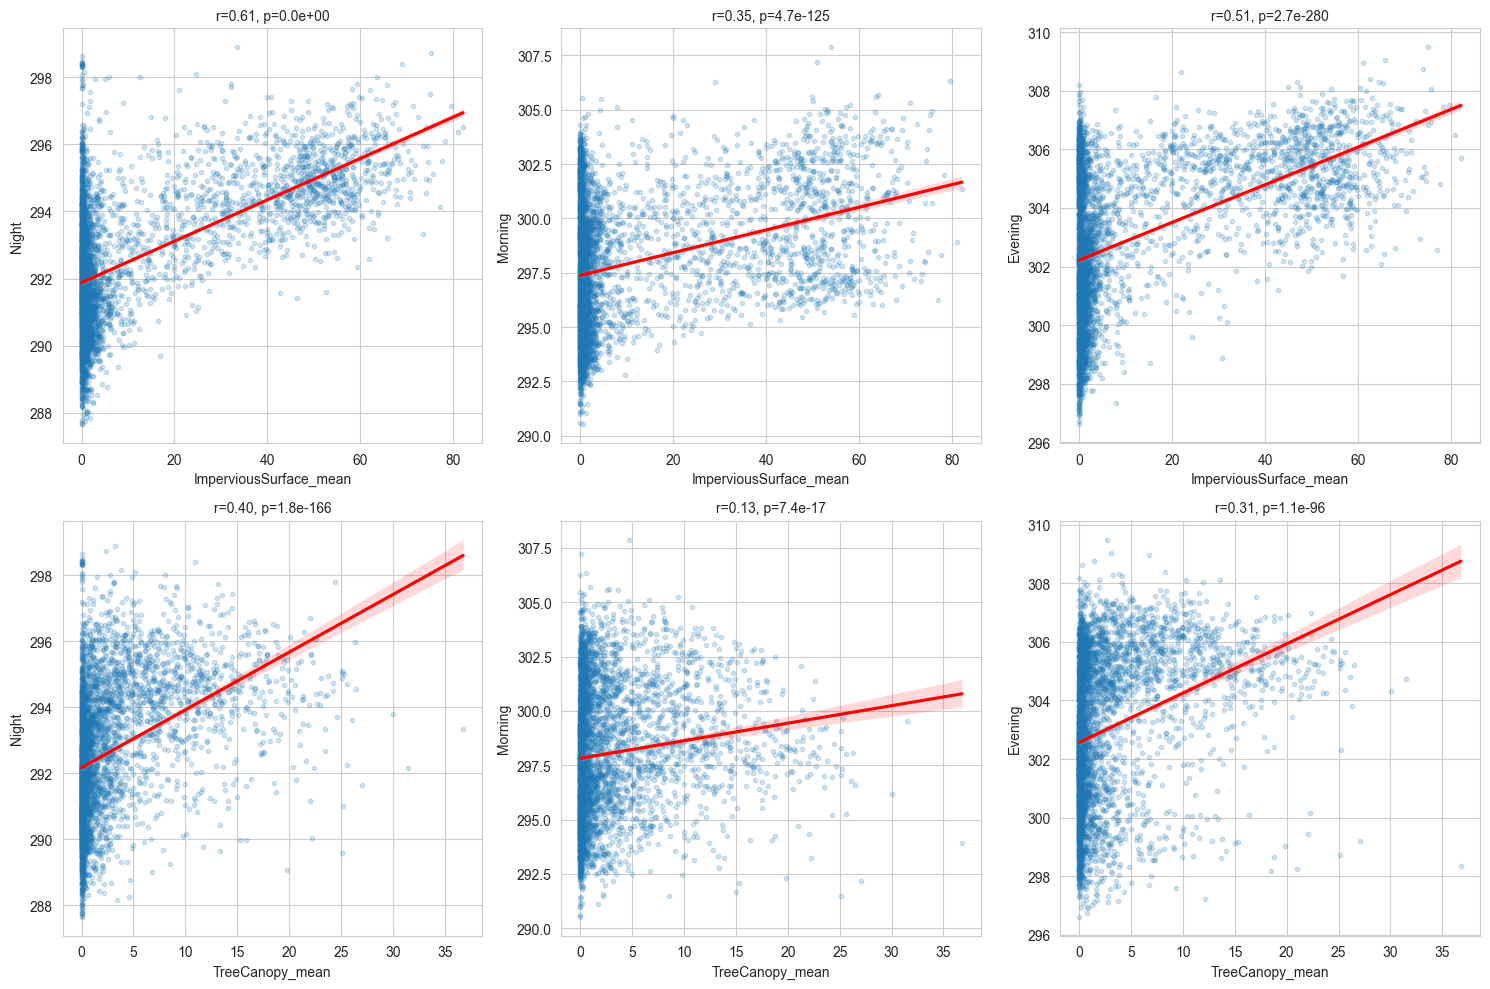

In [7]:
fig, axes = plt.subplots(len(CONTINUOUS_PREDICTORS), len(RESPONSE_VARS),
                           figsize=(5 * len(RESPONSE_VARS), 5 * len(CONTINUOUS_PREDICTORS)))

if len(CONTINUOUS_PREDICTORS) == 1:
    axes = axes.reshape(1, -1)
if len(RESPONSE_VARS) == 1:
    axes = axes.reshape(-1, 1)

for i, pred in enumerate(CONTINUOUS_PREDICTORS):
    for j, resp in enumerate(RESPONSE_VARS):
        ax = axes[i, j]
        sns.regplot(
            data=analysis_df, x=pred, y=resp, ax=ax,
            scatter_kws={"alpha": 0.2, "s": 10}, line_kws={"color": "red"}
        )
        r, p = stats.pearsonr(analysis_df[pred], analysis_df[resp])
        ax.set_title(f"r={r:.2f}, p={p:.1e}", fontsize=10)

plt.tight_layout()
plt.show()

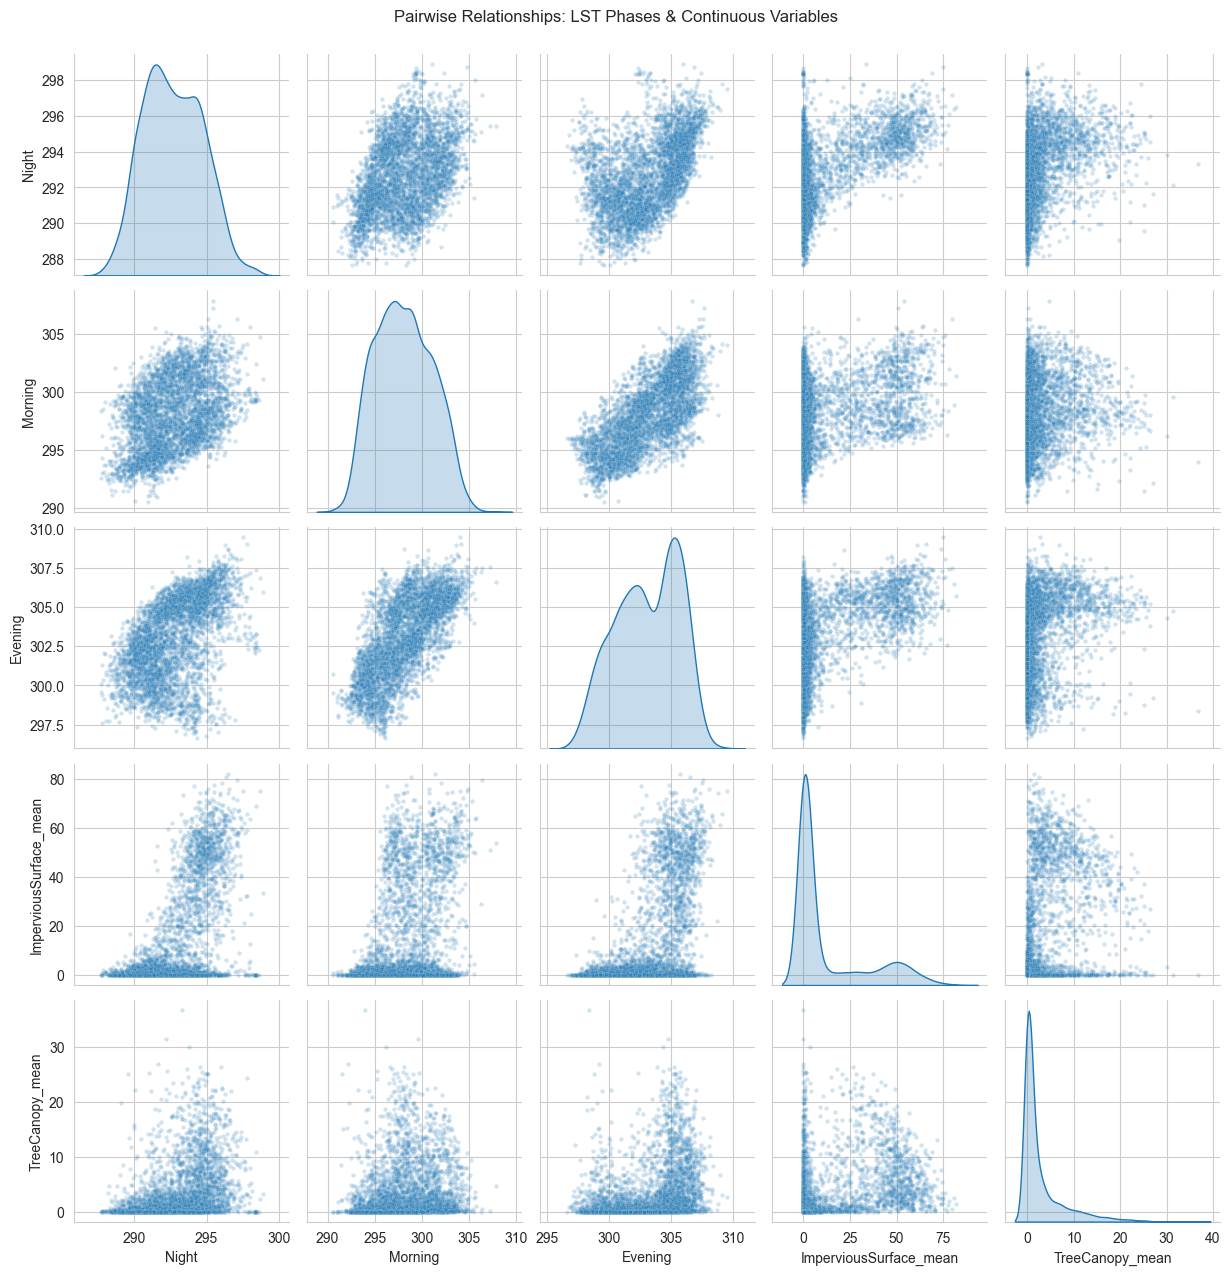

In [8]:
sns.pairplot(analysis_df[corr_cols], diag_kind="kde", plot_kws={"alpha": 0.2, "s": 10})
plt.suptitle("Pairwise Relationships: LST Phases & Continuous Variables", y=1.02)
plt.show()

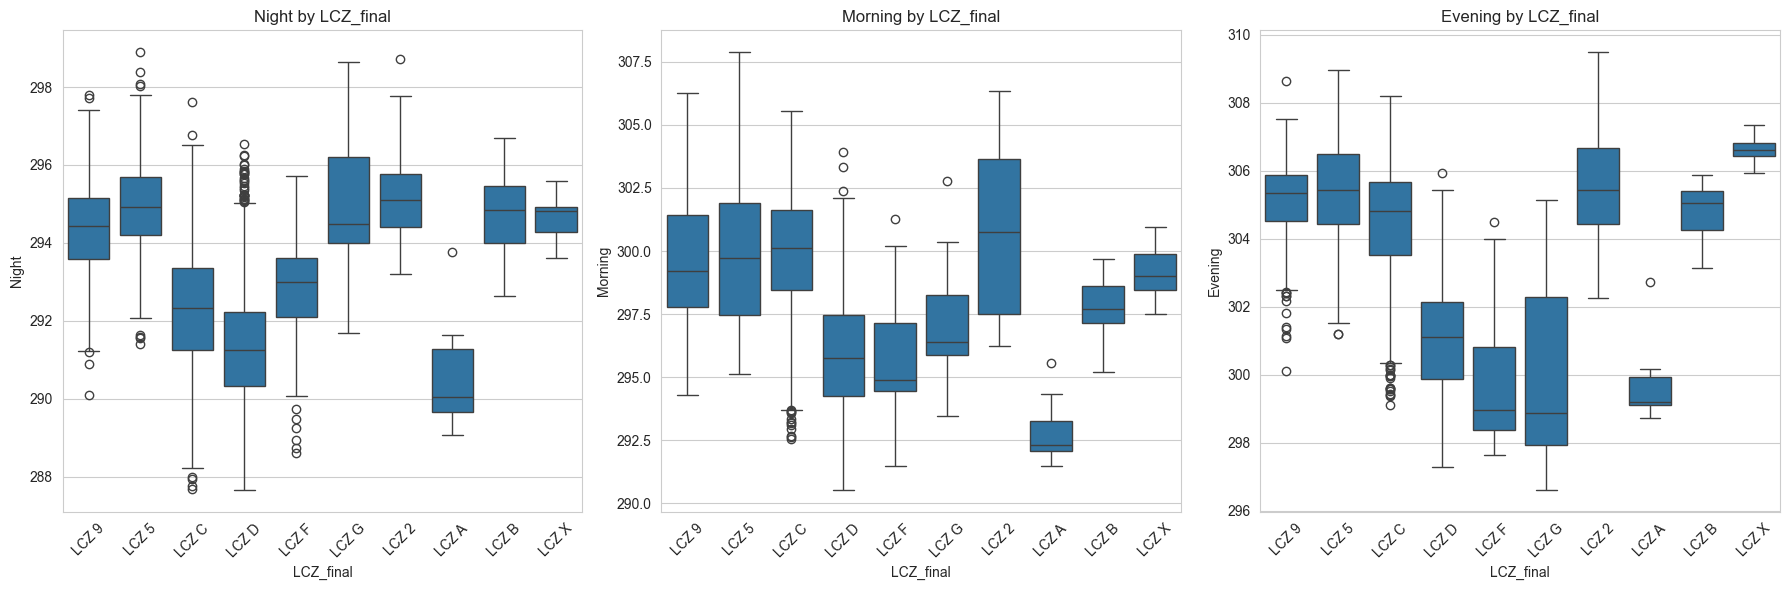

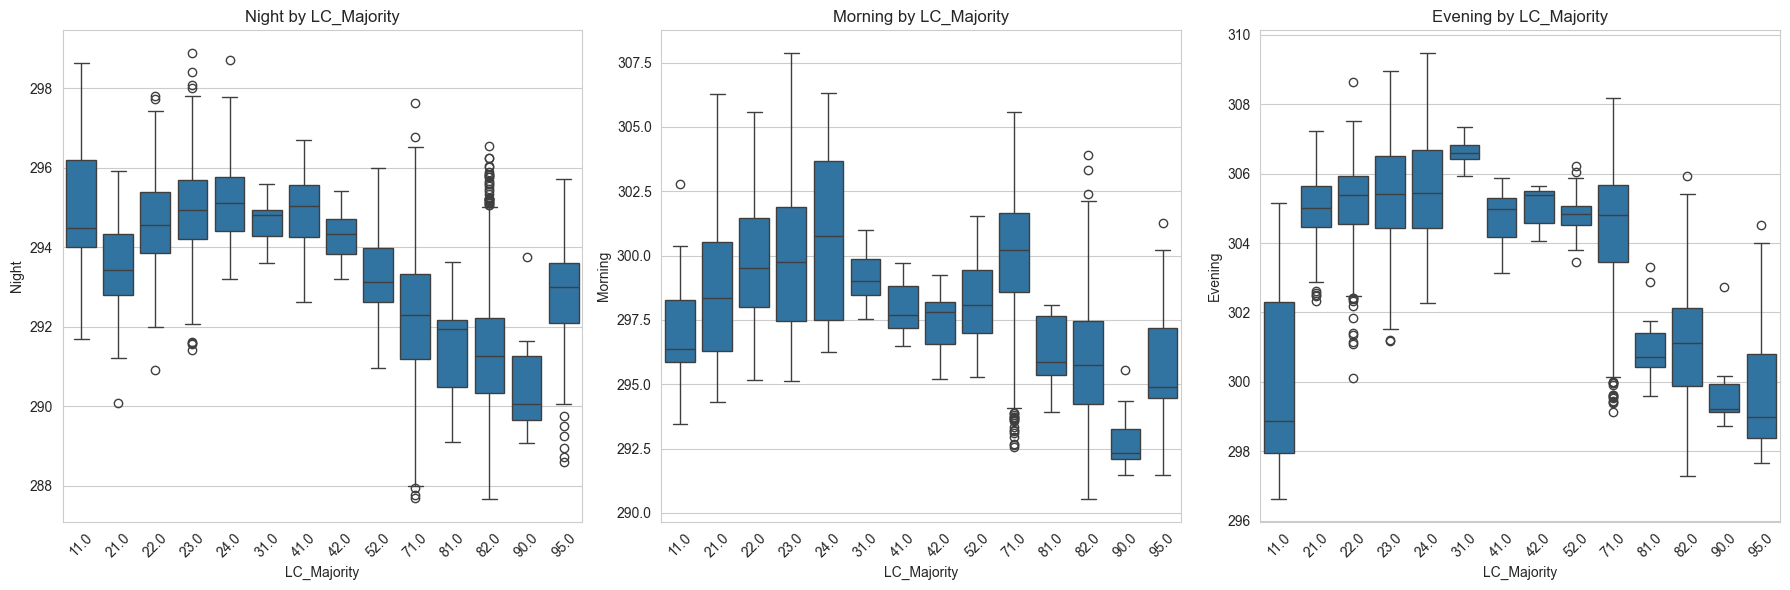

In [9]:
def plot_response_by_category(df, cat_col, response_vars, top_n=15):
    """
    Boxplot of each response variable grouped by category.
    If a category has many levels, only the top_n most frequent are shown
    so the plot stays readable.
    """
    top_categories = df[cat_col].value_counts().head(top_n).index
    plot_df = df[df[cat_col].isin(top_categories)]

    fig, axes = plt.subplots(1, len(response_vars), figsize=(6 * len(response_vars), 6))
    if len(response_vars) == 1:
        axes = [axes]

    for ax, resp in zip(axes, response_vars):
        sns.boxplot(data=plot_df, x=cat_col, y=resp, ax=ax)
        ax.set_title(f"{resp} by {cat_col}")
        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


plot_response_by_category(analysis_df, "LCZ_final", RESPONSE_VARS)
plot_response_by_category(analysis_df, "LC_Majority", RESPONSE_VARS)

In [10]:
def test_categorical_association(df, cat_col, response_vars):
    """
    For each response variable, tests whether its mean/distribution differs
    significantly across the levels of cat_col.
    Runs both one-way ANOVA (assumes normality) and Kruskal-Wallis
    (non-parametric, more robust) for comparison.
    """
    results = []

    for resp in response_vars:
        groups = [
            g[resp].dropna().values
            for _, g in df.dropna(subset=[cat_col, resp]).groupby(cat_col)
            if len(g) > 1
        ]

        if len(groups) < 2:
            continue

        f_stat, anova_p = stats.f_oneway(*groups)
        h_stat, kruskal_p = stats.kruskal(*groups)

        results.append({
            "response": resp,
            "categorical_var": cat_col,
            "anova_F": f_stat,
            "anova_p": anova_p,
            "kruskal_H": h_stat,
            "kruskal_p": kruskal_p,
        })

    return pd.DataFrame(results)


lcz_test_results = test_categorical_association(analysis_df, "LCZ_final", RESPONSE_VARS)
lc_test_results = test_categorical_association(analysis_df, "LC_Majority", RESPONSE_VARS)

print("LCZ_final association with LST phases:")
print(lcz_test_results)

print("\nLC_Majority association with LST phases:")
print(lc_test_results)

LCZ_final association with LST phases:
  response categorical_var     anova_F  anova_p    kruskal_H  kruskal_p
0    Night       LCZ_final  453.790833      0.0  2106.896483        0.0
1  Morning       LCZ_final  327.827789      0.0  1782.358785        0.0
2  Evening       LCZ_final  811.569641      0.0  2696.390211        0.0

LC_Majority association with LST phases:
  response categorical_var     anova_F  anova_p    kruskal_H  kruskal_p
0    Night     LC_Majority  321.268097      0.0  2131.879741        0.0
1  Morning     LC_Majority  230.984589      0.0  1803.005334        0.0
2  Evening     LC_Majority  562.090698      0.0  2697.744071        0.0


In [11]:
def cramers_v(cat1, cat2):
    """Cramér's V: measures association strength between two categorical variables (0-1)."""
    contingency = pd.crosstab(cat1, cat2)
    chi2 = stats.chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else np.nan


valid = analysis_df.dropna(subset=["LC_Majority", "LCZ_final"])
v = cramers_v(valid["LC_Majority"], valid["LCZ_final"])
print(f"Cramér's V between LC_Majority and LCZ_final: {v:.3f}")
print("(0 = no association, 1 = perfect association — a high value here is expected, "
      "since LCZ_final is partly derived FROM LC_Majority)")

Cramér's V between LC_Majority and LCZ_final: 1.000
(0 = no association, 1 = perfect association — a high value here is expected, since LCZ_final is partly derived FROM LC_Majority)


In [12]:
def compute_vif(df, continuous_cols, categorical_cols, drop_first=True):
    """
    Builds a design matrix from continuous predictors and one-hot encoded
    categorical predictors, then computes VIF for each column.
    A VIF > 5 (or > 10, depending on your threshold of choice) suggests
    problematic multicollinearity.
    """
    design_df = df[continuous_cols].copy()

    for cat_col in categorical_cols:
        dummies = pd.get_dummies(
            df[cat_col].astype(str), prefix=cat_col, drop_first=drop_first
        )
        design_df = pd.concat([design_df, dummies], axis=1)

    design_df = design_df.dropna()
    design_df = design_df.astype(float)
    design_with_const = add_constant(design_df)

    vif_data = pd.DataFrame()
    vif_data["variable"] = design_with_const.columns
    vif_data["VIF"] = [
        variance_inflation_factor(design_with_const.values, i)
        for i in range(design_with_const.shape[1])
    ]

    return vif_data[vif_data["variable"] != "const"].sort_values("VIF", ascending=False)


vif_results = compute_vif(analysis_df, CONTINUOUS_PREDICTORS, CATEGORICAL_PREDICTORS)
print(vif_results.to_string(index=False))

              variable       VIF
      LC_Majority_82.0       inf
      LC_Majority_90.0       inf
       LCZ_final_LCZ G       inf
       LCZ_final_LCZ F       inf
       LCZ_final_LCZ D       inf
       LCZ_final_LCZ C       inf
       LCZ_final_LCZ B       inf
       LCZ_final_LCZ A       inf
       LCZ_final_LCZ 9       inf
       LCZ_final_LCZ 5       inf
      LC_Majority_95.0       inf
       LCZ_final_LCZ X       inf
      LC_Majority_81.0       inf
      LC_Majority_71.0       inf
      LC_Majority_52.0       inf
      LC_Majority_42.0       inf
      LC_Majority_41.0       inf
      LC_Majority_31.0       inf
      LC_Majority_24.0       inf
      LC_Majority_23.0       inf
      LC_Majority_22.0       inf
      LC_Majority_21.0       inf
ImperviousSurface_mean 10.129231
       TreeCanopy_mean  2.019026


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [13]:
# Since including two heavily-related categorical variables (LC_Majority and
# LCZ_final) as dummies will likely inflate VIFs across the board (as flagged
# in Cell 11), this simpler check isolates just the two continuous predictors,
# which is often the more interpretable version of a VIF check.
vif_continuous_only = compute_vif(analysis_df, CONTINUOUS_PREDICTORS, [])
print(vif_continuous_only.to_string(index=False))

              variable      VIF
ImperviousSurface_mean 1.177916
       TreeCanopy_mean 1.177916


In [14]:
def run_ols(df, response, predictors):
    X = df[predictors].dropna()
    y = df.loc[X.index, response]
    X_const = add_constant(X)

    model = sm.OLS(y, X_const).fit()
    return model


for resp in RESPONSE_VARS:
    print(f"\n{'='*60}\nOLS: {resp} ~ ImperviousSurface_mean + TreeCanopy_mean\n{'='*60}")
    model = run_ols(analysis_df, resp, CONTINUOUS_PREDICTORS)
    print(model.summary())


OLS: Night ~ ImperviousSurface_mean + TreeCanopy_mean
                            OLS Regression Results                            
Dep. Variable:                  Night   R-squared:                       0.404
Model:                            OLS   Adj. R-squared:                  0.404
Method:                 Least Squares   F-statistic:                     1442.
Date:                Fri, 03 Jul 2026   Prob (F-statistic):               0.00
Time:                        19:39:28   Log-Likelihood:                -7978.3
No. Observations:                4255   AIC:                         1.596e+04
Df Residuals:                    4252   BIC:                         1.598e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

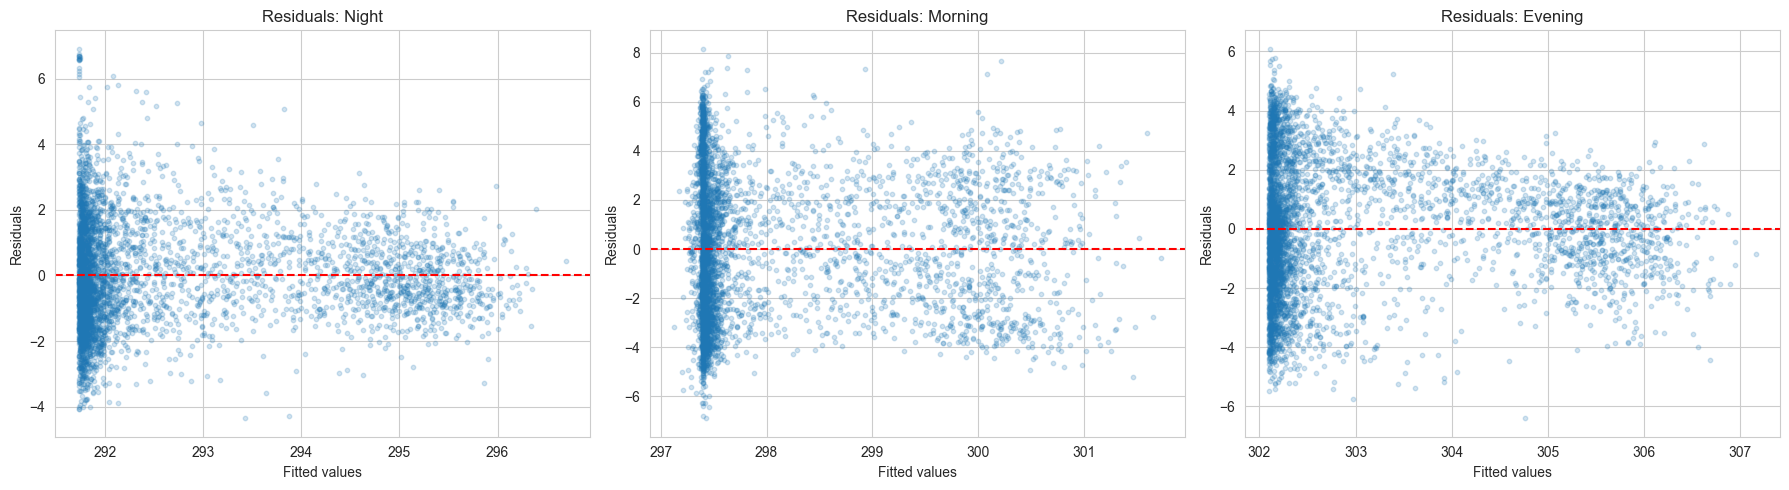

In [15]:
fig, axes = plt.subplots(1, len(RESPONSE_VARS), figsize=(6 * len(RESPONSE_VARS), 5))
if len(RESPONSE_VARS) == 1:
    axes = [axes]

for ax, resp in zip(axes, RESPONSE_VARS):
    model = run_ols(analysis_df, resp, CONTINUOUS_PREDICTORS)
    ax.scatter(model.fittedvalues, model.resid, alpha=0.2, s=10)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_xlabel("Fitted values")
    ax.set_ylabel("Residuals")
    ax.set_title(f"Residuals: {resp}")

plt.tight_layout()
plt.show()

In [16]:
summary_rows = []
for pred in CONTINUOUS_PREDICTORS:
    for resp in RESPONSE_VARS:
        r, p = stats.pearsonr(analysis_df[pred], analysis_df[resp])
        summary_rows.append({
            "predictor": pred, "response": resp,
            "pearson_r": r, "p_value": p,
            "significant_at_0.05": p < 0.05,
        })

summary_df = pd.DataFrame(summary_rows).sort_values("pearson_r", key=abs, ascending=False)
print(summary_df.to_string(index=False))

             predictor response  pearson_r       p_value  significant_at_0.05
ImperviousSurface_mean    Night   0.609380  0.000000e+00                 True
ImperviousSurface_mean  Evening   0.509797 2.724593e-280                 True
       TreeCanopy_mean    Night   0.403627 1.781754e-166                 True
ImperviousSurface_mean  Morning   0.352941 4.738780e-125                 True
       TreeCanopy_mean  Evening   0.311931  1.135102e-96                 True
       TreeCanopy_mean  Morning   0.127371  7.429774e-17                 True
